# 3D mesh tallies

Mesh tallies can also be used to visualise neutron interactions spatially throughout a geometry in 3D.

This notebook allows users to create a simple geometry from a few different materials and plot the results of a 3D regular mesh tally applied to the geometry.

This first code block defines the model geometry, materials and neutron source.

First import OpenMC and configure the nuclear data path

In [1]:
import openmc
from pathlib import Path
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'

In [2]:
# MATERIALS

breeder_material = openmc.Material()   # Pb84.2Li15.8
breeder_material.add_element('Pb', 84.2, percent_type='ao')
breeder_material.add_element('Li', 15.8, percent_type='ao', enrichment=7.0, enrichment_target='Li6', enrichment_type='ao')   # natural enrichment = 7% Li6
breeder_material.set_density('atom/b-cm', 3.2720171e-2)   # around 11 g/cm3

copper_material = openmc.Material()
copper_material.set_density('g/cm3', 8.5)
copper_material.add_element('Cu', 1.0)

eurofer_material = openmc.Material()
eurofer_material.set_density('g/cm3', 7.75)
eurofer_material.add_element('Fe', 89.067, percent_type='wo')

mats = openmc.Materials([breeder_material, eurofer_material, copper_material])


# GEOMETRY

# surfaces
central_sol_surface = openmc.ZCylinder(r=100)
central_shield_outer_surface = openmc.ZCylinder(r=110)
vessel_inner_surface = openmc.Sphere(r=500)
first_wall_outer_surface = openmc.Sphere(r=510)
breeder_blanket_outer_surface = openmc.Sphere(r=610, boundary_type='vacuum')

# cells
central_sol_region = -central_sol_surface & -breeder_blanket_outer_surface
central_sol_cell = openmc.Cell(region=central_sol_region)
central_sol_cell.fill = copper_material

central_shield_region = +central_sol_surface & -central_shield_outer_surface & -breeder_blanket_outer_surface
central_shield_cell = openmc.Cell(region=central_shield_region)
central_shield_cell.fill = eurofer_material

inner_vessel_region = -vessel_inner_surface & +central_shield_outer_surface
inner_vessel_cell = openmc.Cell(region=inner_vessel_region)
# no material set as default is vacuum

first_wall_region = -first_wall_outer_surface & +vessel_inner_surface
first_wall_cell = openmc.Cell(region=first_wall_region)
first_wall_cell.fill = eurofer_material

breeder_blanket_region = +first_wall_outer_surface & -breeder_blanket_outer_surface & +central_shield_outer_surface
breeder_blanket_cell = openmc.Cell(region=breeder_blanket_region)
breeder_blanket_cell.fill = breeder_material

my_geometry = openmc.Geometry([central_sol_cell, central_shield_cell, inner_vessel_cell, first_wall_cell, breeder_blanket_cell])


# SIMULATION SETTINGS

# Instantiate a Settings object
sett = openmc.Settings()
batches = 2
sett.batches = batches
sett.inactive = 0
sett.particles = 5000
sett.run_mode = 'fixed source'

# Create a DT point source
source = openmc.IndependentSource()
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Discrete([14e6], [1])
source.space = openmc.stats.Point((150, 150, 0))

sett.source = source

This code block creates a 3D regular mesh between two coordinates with a specified resolution in each axis.

In [3]:
# Create mesh which will be used for tally
mesh = openmc.RegularMesh().from_domain(
    my_geometry, # the corners of the mesh are being set automatically to surround the geometry
    dimension=[10, 20, 30] # 100 voxels in each axis direction (r, z, phi)
)

This code block creates two tallies on the mesh to record heating and tritium production.

In [4]:
tallies = openmc.Tallies()
# Create mesh filter for tally
mesh_filter = openmc.MeshFilter(mesh)

# Create flux mesh tally to score flux
mesh_tally_1 = openmc.Tally(name='tbr_on_mesh')
mesh_tally_1.filters = [mesh_filter]
mesh_tally_1.scores = ['(n,Xt)']  # where X is a wildcard
tallies.append(mesh_tally_1)

# Create flux mesh tally to score flux
mesh_tally_2 = openmc.Tally(name='heating_on_mesh')
mesh_tally_2.filters = [mesh_filter]
mesh_tally_2.scores = ['heating']
tallies.append(mesh_tally_2)

This next code block performs the simulation.

In [5]:
# deletes old statepoint and summary files
!rm s*.h5

# Run OpenMC!
model = openmc.Model(my_geometry, mats, sett, tallies)
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'

sp_filename = model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading Pb207 from /home/jon/nuclear_data/neutron/Pb207.h5
 Reading Pb208 from /home/jon/nuclear_data/neutron/Pb208.h5


 Reading Li6 from /home/jon/nuclear_data/neutron/Li6.h5
 Reading Li7 from /home/jon/nuclear_data/neutron/Li7.h5
 Reading Cu63 from /home/jon/nuclear_data/neutron/Cu63.h5


 Reading Cu65 from /home/jon/nuclear_data/neutron/Cu65.h5


 Reading Fe54 from /home/jon/nuclear_data/neutron/Fe54.h5


...

 Reading Fe57 from /home/jon/nuclear_data/neutron/Fe57.h5


 Reading Fe58 from /home/jon/nuclear_data/neutron/Fe58.h5


 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
 Maximum neutron transport energy: 20000000.0 eV for Li6

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1


 Simulating batch 2


 Creating state point statepoint.2.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 2.7955e+00 seconds
   Reading cross sections          = 2.7606e+00 seconds
 Total time in simulation          = 1.0232e+00 seconds
   Time in transport only          = 9.7997e-01 seconds
   Time in active batches          = 1.0232e+00 seconds
   Time accumulating tallies       = 1.3829e-02 seconds
   Time writing statepoints        = 2.9269e-02 seconds
 Total time for finalization       = 3.5073e-02 seconds
 Total time elapsed                = 3.8634e+00 seconds
 Calculation Rate (active)         = 9773.68 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.14289 +/- 0.00061



This code block runs a python function which extracts the mesh tally data from the statepoint.h5 file and saves it as a vtk file.

In [6]:

# loads up the output file from the simulation
statepoint = openmc.StatePoint(sp_filename)

# extracts the mesh tally by name
my_tbr_tally = statepoint.get_tally(name='tbr_on_mesh')

# converts the tally result into a VTK file
mesh.write_data_to_vtk(
    filename="tbr_tally_on_reg_mesh.vtk",
    datasets={"mean": my_tbr_tally.mean}  # the first "mean" is the name of the data set label inside the vtk file
)

# extracts the mesh tally by name
my_heating_tally = statepoint.get_tally(name='heating_on_mesh')

# converts the tally result into a VTK file
# this time standard deviation error on the tally is added to the vtk file as another data set
# the tally is also scaled from eV per source particle to Joules per source particle 1eV = 1.60218e-19J)
# Try adding another scaling term to multiplying by the number of neutrons emitted per second would which would convert the units to Watts
mesh.write_data_to_vtk(
    filename="heating_tally_on_reg_mesh.vtk",
    datasets={"mean": my_heating_tally.mean * 1.60218e-19, "std_dev": my_heating_tally.std_dev * 1.60218e-19}
)

<StructuredGrid(0x60310ecd6c90) at 0x719a1666c160>

Click on the newly created vtk file in the file explorer to the left and download the vtk files onto your base computer and open them with a VTK file reader such as Paraview or Visit.

Paraview can be downloaded here: https://www.paraview.org/download/.
Visit can be downloaded here: https://wci.llnl.gov/simulation/computer-codes/visit/downloads.

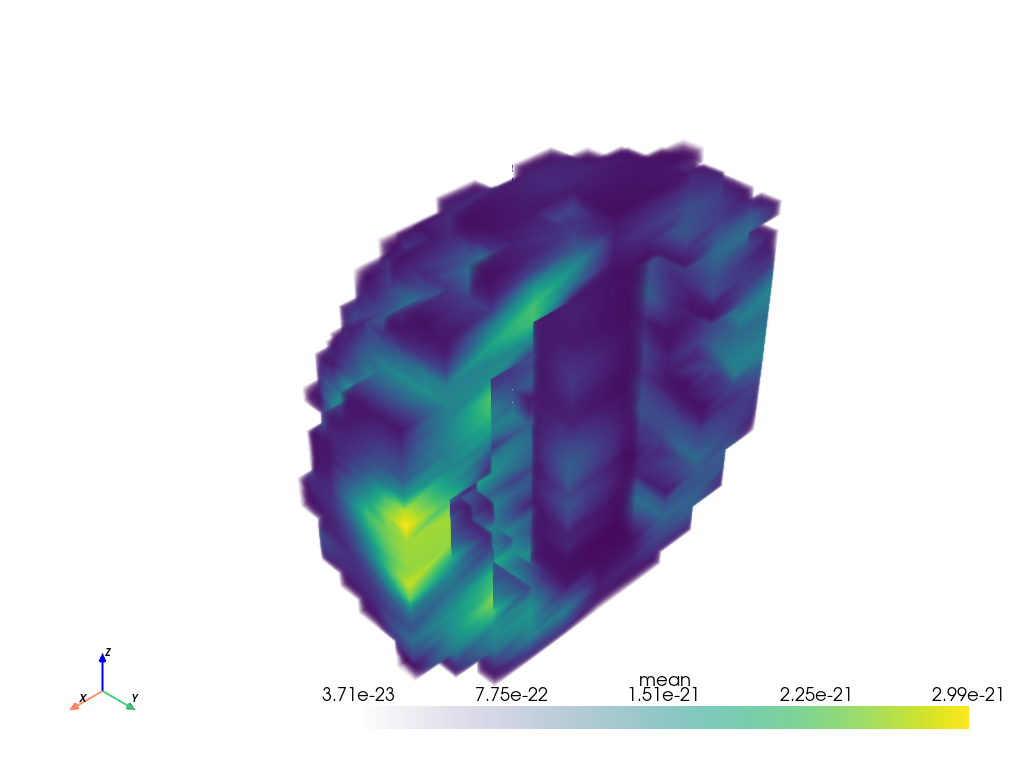

In [7]:
import pyvista as pv
pv.set_jupyter_backend('static')  # setting image to static as interactive plot is difficult ti use in the dockerfile
mesh = pv.read('heating_tally_on_reg_mesh.vtk')
# mesh.plot()
mesh.set_active_scalars(name='mean')

clipped = mesh.clip(normal='y')
clipped_and_thresholded = clipped.threshold_percent(0.01)
clipped_and_thresholded.plot(volume=True)

**Learning Outcomes for Part 2:**

- Mesh tallies can be used in neutronics simulations to measure a variety of different reactions such as neutron absorption, tritium production and flux.
- How neutrons are dissipated around the reactor.